# EMRI Kerr Waveform – LISA SNR Analysis (Paper-Level Pipeline)

This notebook automatically:

1. Generates an EMRI waveform
2. Applies a phase transition correction
3. Computes residual waveform
4. Converts to frequency domain
5. Computes characteristic strain
6. Applies LISA sensitivity curve
7. Computes Signal-to-Noise Ratio (SNR)
8. Computes waveform mismatch
9. **Automatically saves all plots and results**


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.fft import rfft, rfftfreq


## Physical constants

In [2]:
G = 6.67430e-11
c = 299792458
Msun = 1.98847e30
pc = 3.085677581e16


## System parameters

In [3]:
M = 2e5 * Msun
mu = 1.4 * Msun
spin = 0.9
distance = 1e9 * pc


## Inspiral frequency evolution

In [4]:
T = 0.02 * 86400
N = 200000

t = np.linspace(-T,0,N)

f_start = 1e-4
f_end = 0.036

freq_t = f_start + (f_end - f_start) * (t + T) / T


## Baseline waveform

In [5]:
phase = 2*np.pi*np.cumsum(freq_t)*(t[1]-t[0])
amp = 1e-24*(freq_t/f_start)**(2/3)

h_baseline = amp*np.sin(phase)


## Phase transition correction

In [6]:
phase_shift = 0.3*np.exp(t/1500)

h_transition = h_baseline*np.cos(phase_shift) - np.sin(phase_shift)*h_baseline


## Residual waveform

In [7]:
h_residual = h_transition - h_baseline


## Time-domain waveform plot

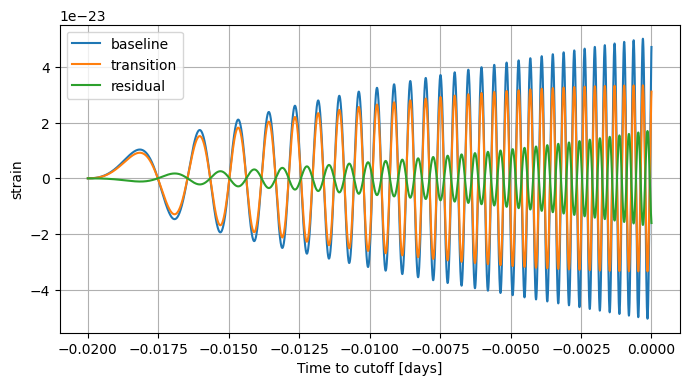

In [8]:
plt.figure(figsize=(8,4))

plt.plot(t/86400, h_baseline, label="baseline")
plt.plot(t/86400, h_transition, label="transition")
plt.plot(t/86400, h_residual, label="residual")

plt.xlabel("Time to cutoff [days]")
plt.ylabel("strain")
plt.legend()
plt.grid()

plt.savefig("waveform_time_domain.png", dpi=300)
plt.show()


## FFT → frequency domain

In [9]:
dt = t[1]-t[0]

freq = rfftfreq(N, dt)

H_baseline = rfft(h_baseline)
H_transition = rfft(h_transition)
H_residual = rfft(h_residual)


## Characteristic strain

In [10]:
hc_baseline = 2*freq*np.abs(H_baseline)
hc_transition = 2*freq*np.abs(H_transition)
hc_residual = 2*freq*np.abs(H_residual)


## LISA noise model

In [11]:
def lisa_psd(f):

    L = 2.5e9
    P_oms = (1.5e-11)**2
    P_acc = (3e-15)**2

    fstar = c/(2*np.pi*L)

    S_oms = P_oms
    S_acc = (4*P_acc)/((2*np.pi*f)**4)

    S = (10/(3*L**2)) * (S_oms + S_acc*(1+(1e-4/f)**2)) * (1 + (f/(0.41*fstar))**2)

    return S


In [12]:
Sn = lisa_psd(freq)
hn = np.sqrt(freq*Sn)


C:\Users\zjy17\AppData\Local\Temp\ipykernel_24436\2807145976.py:10: RuntimeWarning: divide by zero encountered in divide
  S_acc = (4*P_acc)/((2*np.pi*f)**4)
C:\Users\zjy17\AppData\Local\Temp\ipykernel_24436\2807145976.py:12: RuntimeWarning: divide by zero encountered in divide
  S = (10/(3*L**2)) * (S_oms + S_acc*(1+(1e-4/f)**2)) * (1 + (f/(0.41*fstar))**2)
C:\Users\zjy17\AppData\Local\Temp\ipykernel_24436\2318698956.py:2: RuntimeWarning: invalid value encountered in multiply
  hn = np.sqrt(freq*Sn)


## SNR calculation

In [13]:
def compute_snr(hc, hn, f):

    mask = f > 0
    f = f[mask]

    integrand = (hc[mask]/hn[mask])**2
    snr2 = np.trapz(integrand, np.log(f))

    return np.sqrt(snr2)


In [14]:
snr_baseline = compute_snr(hc_baseline,hn,freq)
snr_transition = compute_snr(hc_transition,hn,freq)
snr_residual = compute_snr(hc_residual,hn,freq)

print("Baseline SNR:",snr_baseline)
print("Transition SNR:",snr_transition)
print("Residual SNR:",snr_residual)


Baseline SNR: 5.0638131709604774
Transition SNR: 4.073415456791336
Residual SNR: 1.0507591110106707


## Frequency-domain strain plot

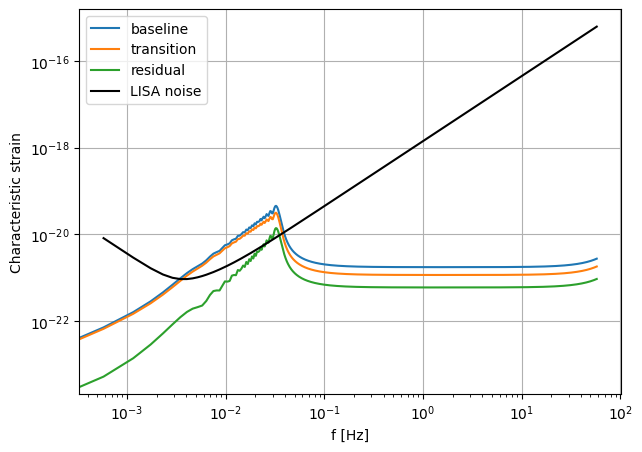

In [15]:
plt.figure(figsize=(7,5))

plt.loglog(freq, hc_baseline, label="baseline")
plt.loglog(freq, hc_transition, label="transition")
plt.loglog(freq, hc_residual, label="residual")

plt.loglog(freq, hn, label="LISA noise", color="black")

plt.xlabel("f [Hz]")
plt.ylabel("Characteristic strain")
plt.legend()
plt.grid()

plt.savefig("frequency_strain.png", dpi=300)
plt.show()


## Waveform mismatch

In [16]:
def inner_product(a,b,Sn,f):

    mask = f>0
    integrand = (a[mask]*np.conj(b[mask]))/Sn[mask]

    val = 4*np.real(np.trapz(integrand,f[mask]))

    return val


In [17]:
def mismatch(h1,h2,Sn,f):

    n1 = inner_product(h1,h1,Sn,f)
    n2 = inner_product(h2,h2,Sn,f)

    ip = inner_product(h1,h2,Sn,f)

    overlap = ip/np.sqrt(n1*n2)

    return 1-overlap


In [18]:
mm = mismatch(H_baseline,H_transition,Sn,freq)

print("Waveform mismatch:",mm)


Waveform mismatch: 0.002986218719360445


## Save SNR results

In [19]:
with open("snr_results.txt","w") as f:

    f.write(f"Baseline SNR: {snr_baseline}\n")
    f.write(f"Transition SNR: {snr_transition}\n")
    f.write(f"Residual SNR: {snr_residual}\n")
    f.write(f"Waveform mismatch: {mm}\n")

print("Results saved to snr_results.txt")


Results saved to snr_results.txt
